# Event Study — Marijuana Legalization & Unemployment

Builds on `01_prelim.ipynb`. Working through this step by step.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


## What is `event_time`?

Take Colorado — `cohort_year = 2012` (the year voters approved recreational legalization). `event_time = year - cohort_year`.

In [23]:
panel = pd.read_csv('../data/processed/marijuana_panel.csv', parse_dates=['date'])

In [24]:
panel.head()

,date,ur,state,year,month,fips,recreational_vote_year,recreational_sales_year,cohort_year,is_treated,event_time
0,2005-01-01,7.1,AK,2005,1,2,2014.0,2016.0,2014.0,True,-9.0
1,2005-02-01,7.0,AK,2005,2,2,2014.0,2016.0,2014.0,True,-9.0
2,2005-03-01,6.9,AK,2005,3,2,2014.0,2016.0,2014.0,True,-9.0
3,2005-04-01,6.9,AK,2005,4,2,2014.0,2016.0,2014.0,True,-9.0
4,2005-05-01,6.8,AK,2005,5,2,2014.0,2016.0,2014.0,True,-9.0


## Collapse to annual

The BLS series is already seasonally adjusted (monthly averages are flat across the year), so there's no reason to pick one month. Take the mean `ur` per state-year instead of an arbitrary month snapshot.

In [25]:
group_cols = ['state', 'year']

annual_ur = panel.groupby(group_cols)['ur'].mean()
annual_ur = annual_ur.reset_index()

annual_meta = panel.groupby(group_cols)[['cohort_year', 'is_treated', 'event_time']].first()
annual_meta = annual_meta.reset_index()

annual_panel = annual_ur.merge(annual_meta, on=group_cols)

annual_panel.head()

,state,year,ur,cohort_year,is_treated,event_time
0,AK,2005,6.925000,2014.0,True,-9.0
1,AK,2006,6.616667,2014.0,True,-8.0
2,AK,2007,6.250000,2014.0,True,-7.0
3,AK,2008,6.508333,2014.0,True,-6.0
4,AK,2009,7.833333,2014.0,True,-5.0


In [26]:
is_co_row = annual_panel['state'] == 'CO'
co = annual_panel[is_co_row]

co[['year', 'cohort_year', 'event_time']]

,year,cohort_year,event_time
38,2005,2012.0,-7.0
39,2006,2012.0,-6.0
40,2007,2012.0,-5.0
41,2008,2012.0,-4.0
42,2009,2012.0,-3.0
43,2010,2012.0,-2.0
44,2011,2012.0,-1.0
45,2012,2012.0,0.0
46,2013,2012.0,1.0
47,2014,2012.0,2.0


In [27]:
co

,state,year,ur,cohort_year,is_treated,event_time
38,CO,2005,5.083333,2012.0,True,-7.0
39,CO,2006,4.250000,2012.0,True,-6.0
40,CO,2007,3.683333,2012.0,True,-5.0
41,CO,2008,4.841667,2012.0,True,-4.0
42,CO,2009,7.950000,2012.0,True,-3.0
43,CO,2010,9.141667,2012.0,True,-2.0
44,CO,2011,8.691667,2012.0,True,-1.0
45,CO,2012,7.991667,2012.0,True,0.0
46,CO,2013,6.725000,2012.0,True,1.0
47,CO,2014,4.950000,2012.0,True,2.0


In [28]:
formula = 'ur ~ event_time' 
model = smf.ols(formula, data=co).fit() 

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ur   R-squared:                       0.144
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     2.866
Date:                Sat, 18 Jul 2026   Prob (F-statistic):              0.109
Time:                        08:52:57   Log-Likelihood:                -39.592
No. Observations:                  19   AIC:                             83.18
Df Residuals:                      17   BIC:                             85.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4011      0.502     10.759      0.000       4.342       6.460
event_time    -0.1457      0.086     -1.693      0.109      -0.327       0.036
==============================================================================
Omnibus:                        5.204   Durbin-Watson:                   0.639
Prob(Omnibus):                  0.074   Jarque-Bera (JB):                2.172
Skew:                           0.501   Prob(JB):                        0.338
Kurtosis:                       1.681   Cond. No.                         6.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# integrate a control region

In [29]:
study_states = ['ID', 'KS', 'NE', 'UT', 'WY', 'CO']
is_study_state = annual_panel['state'].isin(study_states)

study_period = annual_panel[is_study_state]

In [30]:
study_period.head()

,state,year,ur,cohort_year,is_treated,event_time
38,CO,2005,5.083333,2012.0,True,-7.0
39,CO,2006,4.250000,2012.0,True,-6.0
40,CO,2007,3.683333,2012.0,True,-5.0
41,CO,2008,4.841667,2012.0,True,-4.0
42,CO,2009,7.950000,2012.0,True,-3.0


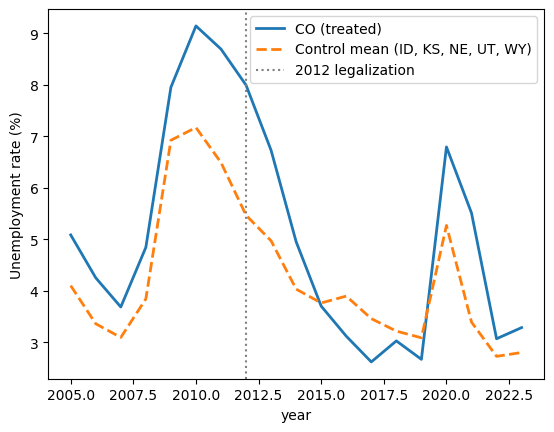

In [31]:
is_control = study_period['state'] != 'CO'
control_rows = study_period[is_control]
control_mean = control_rows.groupby('year')['ur'].mean()

is_co = study_period['state'] == 'CO'
co_rows = study_period[is_co]
co_series = co_rows.set_index('year')['ur']

fig, ax = plt.subplots()

co_series.plot(ax=ax, label='CO (treated)', linewidth=2)
control_mean.plot(ax=ax, label='Control mean (ID, KS, NE, UT, WY)', linewidth=2, linestyle='--')

legalization_year = 2012
ax.axvline(legalization_year, color='gray', linestyle=':', label='2012 legalization')

ax.set_ylabel('Unemployment rate (%)')
ax.legend()

plt.show()

## Pool all treated states

Same idea as the CO-vs-control picture, but now averaged across all 8 treated states, plotted on the `event_time` axis instead of calendar year. This is what lets a single calendar shock (like COVID) land at different points for different cohorts instead of contaminating one spot.

In [32]:
is_treated_group = annual_panel['is_treated'] == True
treated_rows = annual_panel[is_treated_group]

event_time_mean = treated_rows.groupby('event_time')['ur'].mean()
event_time_count = treated_rows.groupby('event_time')['ur'].count()

event_time_mean

event_time
-11.0    4.818750
-10.0    4.614583
-9.0     5.398611
-8.0     6.152778
-7.0     7.630208
-6.0     8.009375
-5.0     8.310417
-4.0     8.053125
-3.0     8.298958
-2.0     7.759375
-1.0     6.884375
 0.0     6.121875
 1.0     5.267708
 2.0     4.694792
 3.0     4.245833
 4.0     7.091667
 5.0     5.089583
 6.0     4.908333
 7.0     4.292708
 8.0     5.950000
 9.0     4.685417
 10.0    3.554167
 11.0    3.750000
Name: ur, dtype: float64

In [33]:
event_time_count

event_time
-11.0    4
-10.0    4
-9.0     6
-8.0     6
-7.0     8
-6.0     8
-5.0     8
-4.0     8
-3.0     8
-2.0     8
-1.0     8
 0.0     8
 1.0     8
 2.0     8
 3.0     8
 4.0     8
 5.0     8
 6.0     8
 7.0     8
 8.0     4
 9.0     4
 10.0    2
 11.0    2
Name: ur, dtype: int64

All 8 treated states cover `event_time` -7 through +7. Outside that window the count drops (only CO/WA reach +10/+11, only the latest cohorts reach -10/-11) — so the tails of the plot below are less reliable, averaged over fewer states.

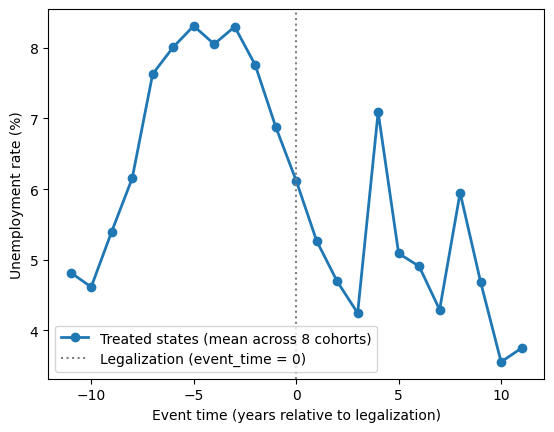

In [34]:
fig, ax = plt.subplots()

event_time_mean.plot(ax=ax, label='Treated states (mean across 8 cohorts)', linewidth=2, marker='o')

reference_event_time = 0
ax.axvline(reference_event_time, color='gray', linestyle=':', label='Legalization (event_time = 0)')

ax.set_xlabel('Event time (years relative to legalization)')
ax.set_ylabel('Unemployment rate (%)')
ax.legend()

plt.show()

## Treated-minus-control gap by event_time

Controls don't have their own `event_time` (never legalized), so we can't just group them the same way. Instead: for every treated state-year, look up the control-group mean `ur` in that *same calendar year*, and subtract it. That difference is a same-year, macro-adjusted gap — averaging it across all treated states by `event_time` should cancel out shared shocks like the 2009 recession or COVID, leaving something closer to an actual treatment-effect shape.

In [35]:
is_control_group = annual_panel['is_treated'] == False
control_rows_all = annual_panel[is_control_group]

control_mean_by_year = control_rows_all.groupby('year')['ur'].mean()
control_mean_by_year.name = 'control_mean'

treated_rows_with_control = treated_rows.merge(control_mean_by_year, on='year')
treated_rows_with_control['gap'] = treated_rows_with_control['ur'] - treated_rows_with_control['control_mean']

treated_rows_with_control[['state', 'year', 'event_time', 'ur', 'control_mean', 'gap']].head()

,state,year,event_time,ur,control_mean,gap
0,AK,2005,-9.0,6.925000,4.098333,2.826667
1,AK,2006,-8.0,6.616667,3.358333,3.258333
2,AK,2007,-7.0,6.250000,3.091667,3.158333
3,AK,2008,-6.0,6.508333,3.840000,2.668333
4,AK,2009,-5.0,7.833333,6.921667,0.911667


In [36]:
gap_mean_by_event_time = treated_rows_with_control.groupby('event_time')['gap'].mean()
gap_count_by_event_time = treated_rows_with_control.groupby('event_time')['gap'].count()

gap_mean_by_event_time

event_time
-11.0    0.720417
-10.0    1.256250
-9.0     1.971389
-8.0     2.473333
-7.0     2.371875
-6.0     2.625625
-5.0     2.562917
-4.0     2.568542
-3.0     2.462292
-2.0     2.586042
-1.0     2.139375
 0.0     1.800625
 1.0     1.356875
 2.0     1.106042
 3.0     0.898750
 4.0     2.680833
 5.0     1.759167
 6.0     1.425417
 7.0     1.273958
 8.0     1.954167
 9.0     1.590417
 10.0    0.829167
 11.0    0.950000
Name: gap, dtype: float64

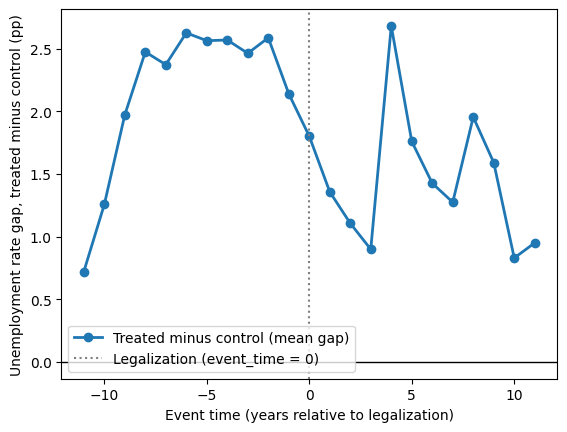

In [37]:
fig, ax = plt.subplots()

gap_mean_by_event_time.plot(ax=ax, label='Treated minus control (mean gap)', linewidth=2, marker='o')

zero_gap = 0
ax.axhline(zero_gap, color='black', linewidth=1)

reference_event_time = 0
ax.axvline(reference_event_time, color='gray', linestyle=':', label='Legalization (event_time = 0)')

ax.set_xlabel('Event time (years relative to legalization)')
ax.set_ylabel('Unemployment rate gap, treated minus control (pp)')
ax.legend()

plt.show()

## Naive TWFE event-study regression

Instead of manually differencing against a same-year control mean, let the regression do it: state fixed effects absorb each state's level, year fixed effects absorb shared shocks (recession, COVID) automatically, and a separate coefficient per `event_time` value shows the dynamic shape.

Control states never have an `event_time` value, so a plain `C(event_time)` would silently drop them from the regression (statsmodels drops any row with a missing value in the formula). We don't want that — controls still need to be in the sample to help pin down the year fixed effects. So give them an explicit `'control'` category instead of `NaN`.

`event_time = -1` (the year right before legalization) is the omitted reference category — every other coefficient is a gap relative to that year.

In [38]:
reg_panel = annual_panel.copy()

is_missing_event_time = reg_panel['event_time'].isna()
reg_panel.loc[is_missing_event_time, 'event_time_cat'] = 'control'

has_event_time = ~is_missing_event_time
reg_panel.loc[has_event_time, 'event_time_cat'] = reg_panel.loc[has_event_time, 'event_time'].astype(int).astype(str)

reg_panel['event_time_cat'].value_counts()

event_time_cat
control    95
-7          8
-6          8
-5          8
-4          8
-3          8
-2          8
-1          8
0           8
1           8
2           8
3           8
4           8
5           8
6           8
7           8
-9          6
-8          6
8           4
9           4
-11         4
-10         4
10          2
11          2
Name: count, dtype: int64

In [39]:
event_time_term = 'C(event_time_cat, Treatment(reference="-1"))'
formula = f'ur ~ C(state) + C(year) + {event_time_term}'

twfe_model = smf.ols(formula, data=reg_panel).fit(
    cov_type='cluster', cov_kwds={'groups': reg_panel['state']}
)

twfe_model.summary()

/Users/stringer/.venvs/data/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 53, but rank is 12
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     ur   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     12.89
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           4.68e-05
Time:                        08:53:01   Log-Likelihood:                -302.80
No. Observations:                 247   AIC:                             711.6
Df Residuals:                     194   BIC:                             897.6
Df Model:                          52                                         
Covariance Type:              cluster                                         
===========================================================================================================================
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                   6.2955      0.422     14.922      0.000       5.469       7.122
C(state)[T.CA]                                              0.7023      0.100      7.045      0.000       0.507       0.898
C(state)[T.CO]                                             -1.4152      0.053    -26.589      0.000      -1.520      -1.311
C(state)[T.ID]                                              0.2226      0.055      4.014      0.000       0.114       0.331
C(state)[T.KS]                                             -0.0432      0.055     -0.778      0.436      -0.152       0.066
C(state)[T.MA]                                             -1.0850      0.100    -10.885      0.000      -1.280      -0.890
C(state)[T.ME]                                             -1.4227      0.100    -14.273      0.000      -1.618      -1.227
C(state)[T.NE]                                             -1.2783      0.055    -23.047      0.000      -1.387      -1.170
C(state)[T.NV]                                              1.0882      0.100     10.917      0.000       0.893       1.284
C(state)[T.OR]                                             -0.3044   9.21e-15   -3.3e+13      0.000      -0.304      -0.304
C(state)[T.UT]                                             -0.6129      0.055    -11.051      0.000      -0.722      -0.504
C(state)[T.WA]                                             -0.4270      0.053     -8.023      0.000      -0.531      -0.323
C(state)[T.WY]                                             -0.1971      0.055     -3.554      0.000      -0.306      -0.088
C(year)[T.2006]                                            -0.8353      0.155     -5.374      0.000      -1.140      -0.531
C(year)[T.2007]                                            -1.1827      0.246     -4.806      0.000      -1.665      -0.700
C(year)[T.2008]                                            -0.3793      0.323     -1.176      0.240      -1.012       0.253
C(year)[T.2009]                                             2.9186      0.518      5.632      0.000       1.903       3.934
C(year)[T.2010]                                             3.3696      0.552      6.107      0.000       2.288       4.451
C(year)[T.2011]                                             2.8748      0.558      5.153      0.000       1.781       3.968
C(year)[T.2012]                                             1.9797      0.523      3.786      0.000       0.955       3.004
C(year)[T.2013]                                             1.3707      0.453      3.024      0.002       0.482       2.259
C(year)[T.2014]                                             0.2761      0.349      0.792      0.428      -0

In [40]:
event_coefs = twfe_model.params.filter(like='event_time_cat')
event_ses = twfe_model.bse.filter(like='event_time_cat')

is_control_term = event_coefs.index.str.contains('control')
event_coefs = event_coefs[~is_control_term]
event_ses = event_ses[~is_control_term]

event_time_values = event_coefs.index.str.extract(r'\[T\.(-?\d+)\]')[0].astype(int)

event_study_df = pd.DataFrame({
    'event_time': event_time_values.values,
    'coef': event_coefs.values,
    'se': event_ses.values,
})

reference_row = pd.DataFrame({'event_time': [-1], 'coef': [0.0], 'se': [0.0]})
event_study_df = pd.concat([event_study_df, reference_row], ignore_index=True)
event_study_df = event_study_df.sort_values('event_time').reset_index(drop=True)

event_study_df

,event_time,coef,se
0,-11,-1.297456,0.856309
1,-10,-0.666358,0.733711
2,-9,0.061817,0.480593
3,-8,0.558838,0.477317
4,-7,0.529021,0.604745
5,-6,0.690689,0.690066
6,-5,0.501502,0.718917
7,-4,0.378178,0.574456
8,-3,0.227704,0.402373
9,-2,0.346488,0.171000


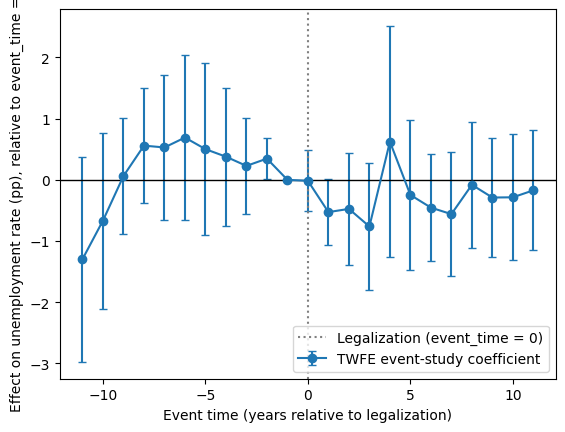

In [41]:
fig, ax = plt.subplots()

ci_95 = 1.96 * event_study_df['se']

ax.errorbar(
    event_study_df['event_time'],
    event_study_df['coef'],
    yerr=ci_95,
    fmt='o-',
    capsize=3,
    label='TWFE event-study coefficient',
)

zero_effect = 0
ax.axhline(zero_effect, color='black', linewidth=1)

reference_event_time = 0
ax.axvline(reference_event_time, color='gray', linestyle=':', label='Legalization (event_time = 0)')

ax.set_xlabel('Event time (years relative to legalization)')
ax.set_ylabel('Effect on unemployment rate (pp), relative to event_time = -1')
ax.legend()

plt.show()

## Wild cluster bootstrap

Only 13 state clusters — too few to trust the asymptotic cluster-robust p-values above. Refit the same specification with `pyfixest` (which has a built-in wild cluster bootstrap) and get a bootstrapped p-value for each `event_time` coefficient instead.

The bootstrap needs the cluster variable as integer codes, not strings — its inner loop is JIT-compiled with `numba`, which chokes on object/string arrays.

In [42]:
import pyfixest as pf

state_categories = reg_panel['state'].astype('category')
reg_panel['state_code'] = state_categories.cat.codes

pf_formula = "ur ~ C(event_time_cat, contr.treatment(base='-1')) + C(state) + C(year)"
pf_fit = pf.feols(pf_formula, data=reg_panel, vcov={'CRV1': 'state_code'})

pf_fit.coef().filter(like='event_time_cat').head()

/Users/stringer/.venvs/data/lib/python3.14/site-packages/pyfixest/estimation/models/feols_.py:2513: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['C(state)[T.WY]'].
            
  warnings.warn(


Coefficient
C(event_time_cat, contr.treatment(base='-1'))[T.-10]   -0.666358
C(event_time_cat, contr.treatment(base='-1'))[T.-11]   -1.297456
C(event_time_cat, contr.treatment(base='-1'))[T.-2]     0.346488
C(event_time_cat, contr.treatment(base='-1'))[T.-3]     0.227704
C(event_time_cat, contr.treatment(base='-1'))[T.-4]     0.378178
Name: Estimate, dtype: float64

In [ ]:
import re

is_event_time_term = pf_fit.coef().index.str.startswith('C(event_time_cat')
is_control_term = pf_fit.coef().index.str.contains('control')
event_terms = pf_fit.coef().index[is_event_time_term & ~is_control_term]

bootstrap_rows = []
for term in event_terms:
    event_time_match = re.search(r'\[T\.(-?\d+)\]', term)
    event_time_value = int(event_time_match.group(1))

    boot_result = pf_fit.wildboottest(reps=4999, param=term, seed=42)

    bootstrap_rows.append({
        'event_time': event_time_value,
        'coef': pf_fit.coef()[term],
        'asymptotic_p': pf_fit.pvalue()[term],
        'bootstrap_p': boot_result['Pr(>|t|)'],
    })

reference_row = pd.DataFrame([{'event_time': -1, 'coef': 0.0, 'asymptotic_p': 1.0, 'bootstrap_p': 1.0}])
bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df = pd.concat([bootstrap_df, reference_row], ignore_index=True)
bootstrap_df = bootstrap_df.sort_values('event_time').reset_index(drop=True)

bootstrap_df

In [ ]:
fig, ax = plt.subplots()

ax.plot(bootstrap_df['event_time'], bootstrap_df['asymptotic_p'], 'o-', label='Asymptotic cluster-robust p-value')
ax.plot(bootstrap_df['event_time'], bootstrap_df['bootstrap_p'], 's--', label='Wild cluster bootstrap p-value')

significance_threshold = 0.05
ax.axhline(significance_threshold, color='red', linestyle=':', label='p = 0.05')

reference_event_time = 0
ax.axvline(reference_event_time, color='gray', linestyle=':', label='Legalization (event_time = 0)')

ax.set_xlabel('Event time (years relative to legalization)')
ax.set_ylabel('p-value')
ax.legend()

plt.show()